In [ ]:
import os, sys

import IPython.display as ipd

path= '/Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation'
path_parts = current_path.split(os.sep)

idx = path_parts.index("occupancy-estimation")

path = os.sep.join(path_parts[:idx + 1])
sys.path.append(path)


In [2]:
import gemmi
import matplotlib.pyplot as plt
import meteor
from occupancy import *
from plotting3d import *

In [4]:
dataloc = "../../synthetic_cistrans/"
pdbname_light = dataloc+"100ps.pdb"
struc_dark = gemmi.read_structure(pdbname_light)
struc_light = gemmi.read_structure(pdbname_light)
from meteor import sfcalc

# st_in = gemmi.read_structure('../tests/1orc.pdb')


# take space group and unit cell from Structure,

# and set size based on the specified minimal spacing

# grid.setup_from(st, spacing=0.6)

In [5]:
target_occ = 0.27
new_occ = 0.14
for x in struc_light[0].all():
    if np.round(x.atom.occ,2)==  target_occ:
        x.atom.occ=new_occ
    elif np.round(x.atom.occ,2) == 1-target_occ:
        x.atom.occ=1-new_occ
    else:
        pass
        # x.atom.occ=0.2
        

Text(0.5, 0, 'Occupancy')

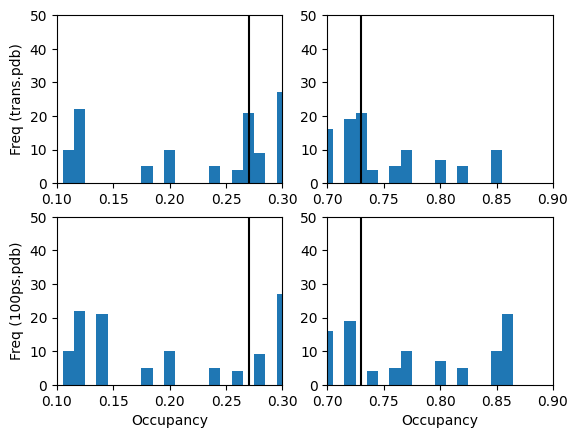

In [6]:
plt.close("all")
fig, axs = plt.subplots(2,2)
ax =axs[0,0]
alpha=0.27
bins = np.linspace(0.005,1.005,101)
for ax in axs.flat:
    ax.axvline(alpha,color="k")
    ax.axvline(1-alpha,color="k")
    ax.set_ylim(0,50)
    
ax =axs[0,0]
ax.hist([np.round(x.atom.occ,2) for x in struc_dark[0].all()], bins = bins)
ax.set_xlim(.1,.3)
ax.set_ylabel("Freq (trans.pdb)")

ax =axs[1,0]
ax.hist([np.round(x.atom.occ,2) for x in struc_light[0].all()], bins = bins)
ax.set_xlim(.1,.3)
ax.set_ylabel("Freq (100ps.pdb)")
ax.set_xlabel("Occupancy")

ax =axs[0,1]
ax.hist([np.round(x.atom.occ,2) for x in struc_dark[0].all()], bins = bins)
ax.set_xlim(.7,.9)

ax =axs[1,1]
ax.hist([np.round(x.atom.occ,2) for x in struc_light[0].all()], bins = bins)
ax.set_xlim(.7,.9)
ax.set_xlabel("Occupancy")

In [7]:
import reciprocalspaceship as rs
import numpy as np

In [8]:
def struc2realspace(struc, hs_limit, noise_level):
    map_vals = meteor.sfcalc.gemmi_structure_to_calculated_map(struc, high_resolution_limit=hs_limit)
    struc_vals=rs.DataSet(map_vals)
    noise = np.random.normal(loc=0.0, scale=noise_level * np.abs(struc_vals["F"]))
    struc_vals["F"] = struc_vals["F"] + noise
    struc_vals["sf"] = struc_vals.to_structurefactor("F","PHI")
    struc_vals_grid = struc_vals.to_reciprocal_grid("sf")
    struc_vals_real = np.fft.ifftn(struc_vals_grid).real
    return struc_vals_real

In [ ]:
arr = struc2realspace(struc_dark, 1.6, 0.1)

plt.close("all")

NameError: name 'st' is not defined

interactive(children=(IntSlider(value=0, description='f0', max=99), Output()), _dom_classes=('widget-interact'…

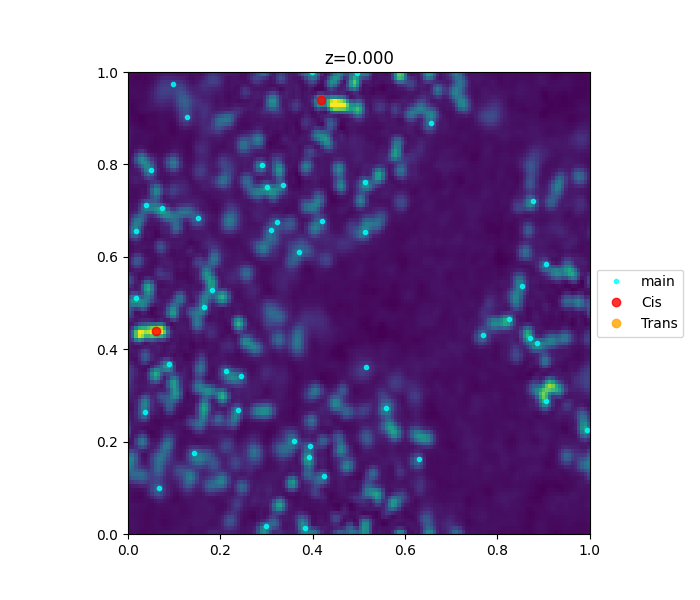

In [115]:
frac_list, occ_mask=get_pos_from_pdb(st, search_occ=0.27)
%matplotlib widget
flist = frac_list.copy()
flist[1] = 1-flist[1]
# _ = mtz_comp(flist,occ_mask,  arr,extent=[1,0,0,1]) 
# _ = mtz_comp(frac_list,occ_mask,  np.flip(arr,(0,)),extent=[1,0,0,1]) 
_ = mtz_comp(frac_list,occ_mask,  np.flip(arr,(0,1,2)),extent=[0,1,1,0]) 

interactive(children=(IntSlider(value=0, description='f0', max=99), Output()), _dom_classes=('widget-interact'…

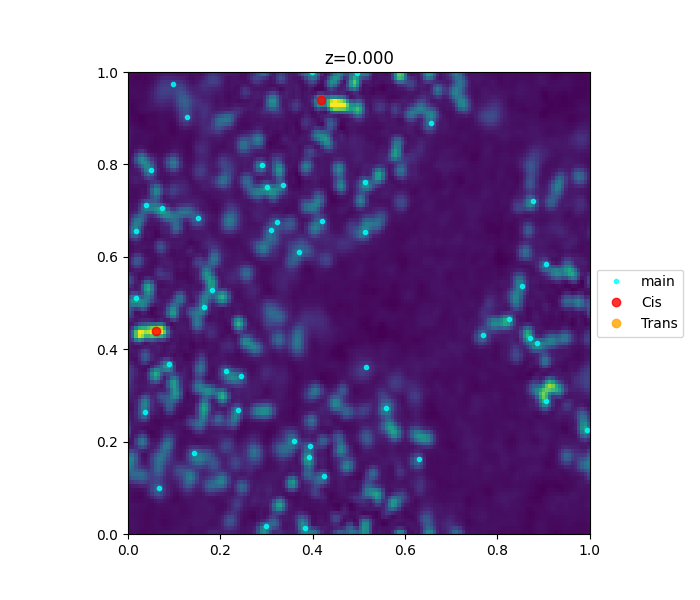

In [72]:
_ = mtz_comp(frac_list,occ_mask,  np.flip(arr,(0,1,2)),extent=[0,1,1,0]) 


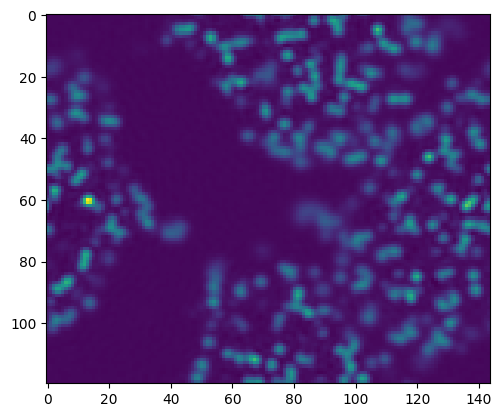

In [20]:
imshow(tv_denoised_real[2])
